=== Exercise 1 ===
R² with AveRooms: 0.0138
R² with MedInc: 0.4589
نتیجه: MedInc پیش‌بینی‌کننده‌ی قوی‌تری است زیرا R² بالاتری دارد.

=== Exercise 2 ===
Three features with smallest absolute coefficients:
  Population: -0.0000
  AveOccup: -0.0035
  HouseAge: 0.0097
توجه: اندازه‌ی ضریب به مقیاس ویژگی بستگی دارد؛ قبل از حذف باید اهمیت آماری و همبستگی را بررسی کرد.
همچنین ممکن است ویژگی‌هایی با ضریب کوچک تأثیر غیرخطی یا تعاملی داشته باشند، بنابراین صرفاً بر اساس اندازه نمی‌توان حذف کرد.

=== Exercise 3 ===


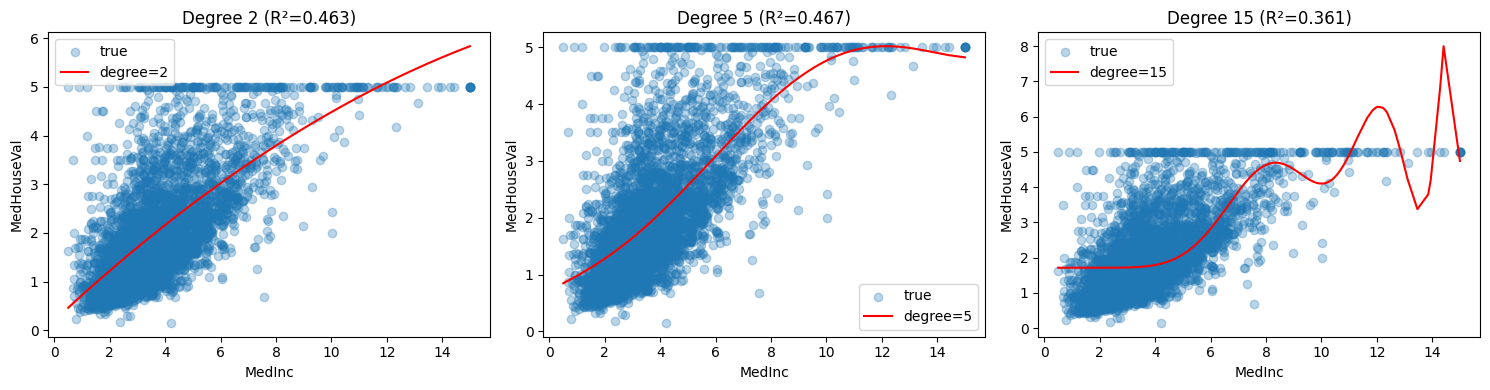

توضیح: درجه‌ی ۵ بین درجه‌ی ۲ (کم‌انعطاف) و درجه‌ی ۱۵ (بیش‌انعطاف و بیش‌برازش) قرار می‌گیرد.
نسبت به درجه‌ی ۲ انعطاف بیشتری دارد و به داده‌ها بهتر برازش می‌کند، اما برخلاف درجه‌ی ۱۵ نوسانات شدید انتهایی ندارد.

=== Exercise 4 ===
Simple model (MedInc):
  MAE = 0.6299, RMSE = 0.8421, R² = 0.4589
Multiple model (all features):
  MAE = 0.5332, RMSE = 0.7456, R² = 0.5758
نتیجه: مدل چندمتغیره در هر سه معیار بهتر عمل می‌کند (MAE و RMSE کمتر، R² بیشتر).

=== Exercise 5 ===
Number of zero coefficients for Lasso (degree=10) with different alpha:
  alpha=0.001: 4 zero coefficients
  alpha=0.01: 7 zero coefficients
  alpha=0.1: 8 zero coefficients
  alpha=1: 10 zero coefficients
نتیجه: با افزایش alpha، تعداد ضرایب صفر بیشتر می‌شود، زیرا Lasso ضرایب را به سمت صفر می‌کشاند و در نهایت ویژگی‌های کم‌اهمیت‌تر حذف می‌شوند.

=== Exercise 6 ===
Best alpha for Ridge: 0.001 with mean negative RMSE = -0.0910 (i.e. RMSE = 0.0910)
Plain linear regression (degree=10) test RMSE: 0.0864
Best Ridge model test RMSE:

c:\Users\user\Desktop\تمرینات کلاس خصوصی\pasokh-kian-va-kiarash\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.546e-01, tolerance: 7.837e-03
  model = cd_fast.enet_coordinate_descent(


In [3]:
# ================================
# کتابخانه‌های مورد نیاز
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# تنظیم دانه تصادفی برای تکرارپذیری
rng = np.random.default_rng(42)
np.random.seed(42)  # برای سازگاری با sklearn

# بارگذاری داده مسکن کالیفرنیا
housing = fetch_california_housing(as_frame=True)
X_full = housing.data
y_full = housing.target

# تقسیم به train/test (۸۰٪ آموزش، ۲۰٪ آزمون)
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# ================================
# تمرین ۱
# ================================
print("=== Exercise 1 ===")
# مدل با AveRooms
model_rooms = LinearRegression()
model_rooms.fit(X_train[['AveRooms']], y_train)
r2_rooms = r2_score(y_test, model_rooms.predict(X_test[['AveRooms']]))

# مدل با MedInc
model_inc = LinearRegression()
model_inc.fit(X_train[['MedInc']], y_train)
r2_inc = r2_score(y_test, model_inc.predict(X_test[['MedInc']]))

print(f"R² with AveRooms: {r2_rooms:.4f}")
print(f"R² with MedInc: {r2_inc:.4f}")
print("نتیجه: MedInc پیش‌بینی‌کننده‌ی قوی‌تری است زیرا R² بالاتری دارد.")
print()

# ================================
# تمرین ۲
# ================================
print("=== Exercise 2 ===")
# مدل چندمتغیره با تمام ویژگی‌ها
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)
coefs = model_multi.coef_
feature_names = X_full.columns
# سه ویژگی با کوچک‌ترین قدر مطلق ضریب
sorted_idx = np.argsort(np.abs(coefs))
smallest_three = [(feature_names[i], coefs[i]) for i in sorted_idx[:3]]
print("Three features with smallest absolute coefficients:")
for feat, coef in smallest_three:
    print(f"  {feat}: {coef:.4f}")
print("توجه: اندازه‌ی ضریب به مقیاس ویژگی بستگی دارد؛ قبل از حذف باید اهمیت آماری و همبستگی را بررسی کرد.")
print("همچنین ممکن است ویژگی‌هایی با ضریب کوچک تأثیر غیرخطی یا تعاملی داشته باشند، بنابراین صرفاً بر اساس اندازه نمی‌توان حذف کرد.")
print()

# ================================
# تمرین ۳
# ================================
print("=== Exercise 3 ===")
# ایجاد داده‌های چندجمله‌ای برای درجه‌های ۲، ۵ و ۱۵
# از ستون MedInc به عنوان مثال استفاده می‌کنیم (مانند بخش ۷.۲)
X_inc_train = X_train[['MedInc']].values
X_inc_test = X_test[['MedInc']].values

degrees = [2, 5, 15]
plt.figure(figsize=(15, 4))
for i, d in enumerate(degrees):
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly_train = poly.fit_transform(X_inc_train)
    X_poly_test = poly.transform(X_inc_test)
    model = LinearRegression()
    model.fit(X_poly_train, y_train)
    y_pred = model.predict(X_poly_test)
    r2 = r2_score(y_test, y_pred)
    
    plt.subplot(1, 3, i+1)
    plt.scatter(X_inc_test, y_test, alpha=0.3, label='true')
    # مرتب‌سازی برای رسم خط
    idx_sort = np.argsort(X_inc_test.ravel())
    plt.plot(X_inc_test[idx_sort], y_pred[idx_sort], 'r-', label=f'degree={d}')
    plt.xlabel('MedInc')
    plt.ylabel('MedHouseVal')
    plt.title(f'Degree {d} (R²={r2:.3f})')
    plt.legend()
plt.tight_layout()
plt.show()
print("توضیح: درجه‌ی ۵ بین درجه‌ی ۲ (کم‌انعطاف) و درجه‌ی ۱۵ (بیش‌انعطاف و بیش‌برازش) قرار می‌گیرد.")
print("نسبت به درجه‌ی ۲ انعطاف بیشتری دارد و به داده‌ها بهتر برازش می‌کند، اما برخلاف درجه‌ی ۱۵ نوسانات شدید انتهایی ندارد.")
print()

# ================================
# تمرین ۴
# ================================
print("=== Exercise 4 ===")
# مدل ساده با MedInc
y_pred_simple = model_inc.predict(X_test[['MedInc']])
mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2_simple = r2_score(y_test, y_pred_simple)

# مدل چندمتغیره
y_pred_multi = model_multi.predict(X_test)
mae_multi = mean_absolute_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)

print("Simple model (MedInc):")
print(f"  MAE = {mae_simple:.4f}, RMSE = {rmse_simple:.4f}, R² = {r2_simple:.4f}")
print("Multiple model (all features):")
print(f"  MAE = {mae_multi:.4f}, RMSE = {rmse_multi:.4f}, R² = {r2_multi:.4f}")
print("نتیجه: مدل چندمتغیره در هر سه معیار بهتر عمل می‌کند (MAE و RMSE کمتر، R² بیشتر).")
print()

# ================================
# تمرین ۵
# ================================
print("=== Exercise 5 ===")
# تولید داده‌ی مصنوعی مشابه بخش ۹ (y = sin(2πx) + noise)
n_samples = 200
X_syn = np.linspace(0, 1, n_samples).reshape(-1, 1)
y_syn = np.sin(2 * np.pi * X_syn.ravel()) + rng.normal(0, 0.1, n_samples)

# تقسیم داده‌ی مصنوعی (برای تمرین، همه را یکجا استفاده می‌کنیم، اما بهتر است split کنیم)
X_syn_train, X_syn_test, y_syn_train, y_syn_test = train_test_split(X_syn, y_syn, test_size=0.2, random_state=42)

# برای Lasso با درجه ۱۰
degree = 10
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly_train = poly.fit_transform(X_syn_train)
X_poly_test = poly.transform(X_syn_test)

# مقیاس‌سازی (توصیه شده برای Lasso/Ridge)
scaler = StandardScaler()
X_poly_train_scaled = scaler.fit_transform(X_poly_train)
X_poly_test_scaled = scaler.transform(X_poly_test)

alphas = [0.001, 0.01, 0.1, 1]
print(f"Number of zero coefficients for Lasso (degree={degree}) with different alpha:")
for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42)
    lasso.fit(X_poly_train_scaled, y_syn_train)
    zero_count = np.sum(np.abs(lasso.coef_) < 1e-10)
    print(f"  alpha={alpha}: {zero_count} zero coefficients")
print("نتیجه: با افزایش alpha، تعداد ضرایب صفر بیشتر می‌شود، زیرا Lasso ضرایب را به سمت صفر می‌کشاند و در نهایت ویژگی‌های کم‌اهمیت‌تر حذف می‌شوند.")
print()

# ================================
# تمرین ۶
# ================================
print("=== Exercise 6 ===")
# Ridge با اعتبارسنجی متقابل (همان داده‌ی مصنوعی)
ridge_alphas = [0.001, 0.01, 0.1, 1, 10]
best_score = -np.inf
best_alpha = None
scores = {}
for alpha in ridge_alphas:
    ridge = Ridge(alpha=alpha)
    # از داده‌های پلی‌نومیال مقیاس‌شده استفاده می‌کنیم (برای cv)
    cv_scores = cross_val_score(ridge, X_poly_train_scaled, y_syn_train, cv=5, scoring='neg_root_mean_squared_error')
    mean_score = np.mean(cv_scores)
    scores[alpha] = mean_score
    if mean_score > best_score:
        best_score = mean_score
        best_alpha = alpha

print(f"Best alpha for Ridge: {best_alpha} with mean negative RMSE = {best_score:.4f} (i.e. RMSE = {-best_score:.4f})")

# مدل بدون منظم‌سازی (alpha=0) - معادل LinearRegression
lr = LinearRegression()
lr.fit(X_poly_train_scaled, y_syn_train)
y_pred_lr = lr.predict(X_poly_test_scaled)
rmse_lr = np.sqrt(mean_squared_error(y_syn_test, y_pred_lr))
print(f"Plain linear regression (degree={degree}) test RMSE: {rmse_lr:.4f}")
print(f"Best Ridge model test RMSE: {-best_score:.4f} (approximated from CV)")
print("نتیجه: Ridge با alpha مناسب معمولاً عملکرد بهتری نسبت به مدل بدون منظم‌سازی دارد و از بیش‌برازش جلوگیری می‌کند.")
print()



In [2]:
# ================================
# تمرین ۷
# ================================
print("=== Exercise 7 ===")
# بارگذاری داده‌ی دیابت
diabetes = load_diabetes(as_frame=True)
X_diabetes = diabetes.data
y_diabetes = diabetes.target

# تقسیم
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_diabetes, y_diabetes, test_size=0.2, random_state=42)

# رگرسیون خطی با تمام ۱۰ ویژگی
lr_d = LinearRegression()
lr_d.fit(X_train_d, y_train_d)
y_pred_d = lr_d.predict(X_test_d)

mae_d = mean_absolute_error(y_test_d, y_pred_d)
rmse_d = np.sqrt(mean_squared_error(y_test_d, y_pred_d))
r2_d = r2_score(y_test_d, y_pred_d)

print("Diabetes dataset - Linear Regression with all 10 features:")
print(f"  MAE = {mae_d:.4f}, RMSE = {rmse_d:.4f}, R² = {r2_d:.4f}")

# مقایسه با مسکن کالیفرنیا (مدل چندمتغیره)
print("\nComparison with California housing (multiple model):")
print(f"  CA Housing - MAE: {mae_multi:.4f}, RMSE: {rmse_multi:.4f}, R²: {r2_multi:.4f}")
print(f"  Diabetes   - MAE: {mae_d:.4f}, RMSE: {rmse_d:.4f}, R²: {r2_d:.4f}")
print("نتیجه: داده‌ی دیابت R² بالاتری دارد (نزدیک به ۰.۵) در حالی که مسکن کالیفرنیا R² حدود ۰.۵۸ است (در این split).")
print("بنابراین دیابت نسبتاً ساده‌تر قابل پیش‌بینی است زیرا خطای کمتری دارد (MAE و RMSE کوچک‌تر) و R² بالاتر نشان‌دهنده‌ی برازش بهتر است.")
print("البته مقیاس متغیر هدف متفاوت است؛ باید نسبت به پراکندگی داده‌ها قضاوت کرد.")

=== Exercise 7 ===
Diabetes dataset - Linear Regression with all 10 features:
  MAE = 42.7941, RMSE = 53.8534, R² = 0.4526

Comparison with California housing (multiple model):
  CA Housing - MAE: 0.5332, RMSE: 0.7456, R²: 0.5758
  Diabetes   - MAE: 42.7941, RMSE: 53.8534, R²: 0.4526
نتیجه: داده‌ی دیابت R² بالاتری دارد (نزدیک به ۰.۵) در حالی که مسکن کالیفرنیا R² حدود ۰.۵۸ است (در این split).
بنابراین دیابت نسبتاً ساده‌تر قابل پیش‌بینی است زیرا خطای کمتری دارد (MAE و RMSE کوچک‌تر) و R² بالاتر نشان‌دهنده‌ی برازش بهتر است.
البته مقیاس متغیر هدف متفاوت است؛ باید نسبت به پراکندگی داده‌ها قضاوت کرد.
